# Vietnam SVAR – Oil Shock Analysis
**Data:** `macro_monthly_15y_vnm.csv` | 180 months (2006 → 2024)  
**Variables:** WTI, GDP, CPI, FX_local_per_USD, Interest_rate_percent  
**Ordering (Cholesky):** WTI → GDP → CPI → IntRate → FX

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import VAR
import warnings
warnings.filterwarnings('ignore')

# ── Visualization style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.color':       'white',
    'grid.linewidth':   0.8,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   11,
    'axes.labelsize':   9,
    'xtick.labelsize':  8,
    'ytick.labelsize':  8,
})

COLORS = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd']
VAR_NAMES   = ['ln_WTI', 'ln_GDP', 'ln_CPI', 'IntRate', 'ln_FX']
VAR_LABELS  = ['ln(WTI)', 'ln(GDP)', 'ln(CPI)', 'Interest Rate (%)', 'ln(FX)']
print('Libraries loaded.')

Libraries loaded.


---
## Part 1 · Data Loading & Log Transformation

In [3]:
# ── Load ─────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(
    '../data/macro_monthly_15y_vnm.csv',
    parse_dates=['date'], index_col='date'
)
df_raw = df_raw[['WTI_usd_per_barrel', 'GDP_usd', 'CPI_index',
                 'Interest_rate_percent', 'FX_local_per_USD']]
df_raw.columns = ['WTI', 'GDP', 'CPI', 'IntRate', 'FX']
df_raw.index.freq = 'MS'   # month-start frequency

print(f'Observations : {len(df_raw)}')
print(f'Period       : {df_raw.index[0].date()} → {df_raw.index[-1].date()}')
print(f'Missing      : {df_raw.isna().sum().to_dict()}')
df_raw.head(3)

Observations : 217
Period       : 2006-01-01 → 2024-01-01
Missing      : {'WTI': 0, 'GDP': 0, 'CPI': 0, 'IntRate': 0, 'FX': 0}


,WTI,GDP,CPI,IntRate,FX
date,,,,,
2006-01-01,65.485000,6.637166e+10,64.327239,11.176250,15994.250000
2006-02-01,61.631053,6.729189e+10,64.774552,11.176562,16003.489583
2006-03-01,62.685217,6.821212e+10,65.221865,11.176875,16012.729167


In [ ]:
# ── Log-transform WTI, GDP, CPI, FX  (IntRate kept in levels) ───────────────
df = pd.DataFrame(index=df_raw.index)
df['ln_WTI']  = np.log(df_raw['WTI'])
df['ln_GDP']  = np.log(df_raw['GDP'])
df['ln_CPI']  = np.log(df_raw['CPI'])
df['IntRate'] = df_raw['IntRate']          # level, no log
df['ln_FX']   = np.log(df_raw['FX'])

print('Log-transformed dataframe (first 3 rows):')
df.head(3)

Log-transformed dataframe (first 3 rows):


,ln_WTI,ln_GDP,ln_CPI,IntRate,ln_FX
date,,,,,
2006-01-01,4.181821,24.918536,4.163983,11.176250,9.679985
2006-02-01,4.121166,24.932306,4.170913,11.176562,9.680562
2006-03-01,4.138126,24.945888,4.177795,11.176875,9.681139


### 1.1 Time-series plots – Log-levels

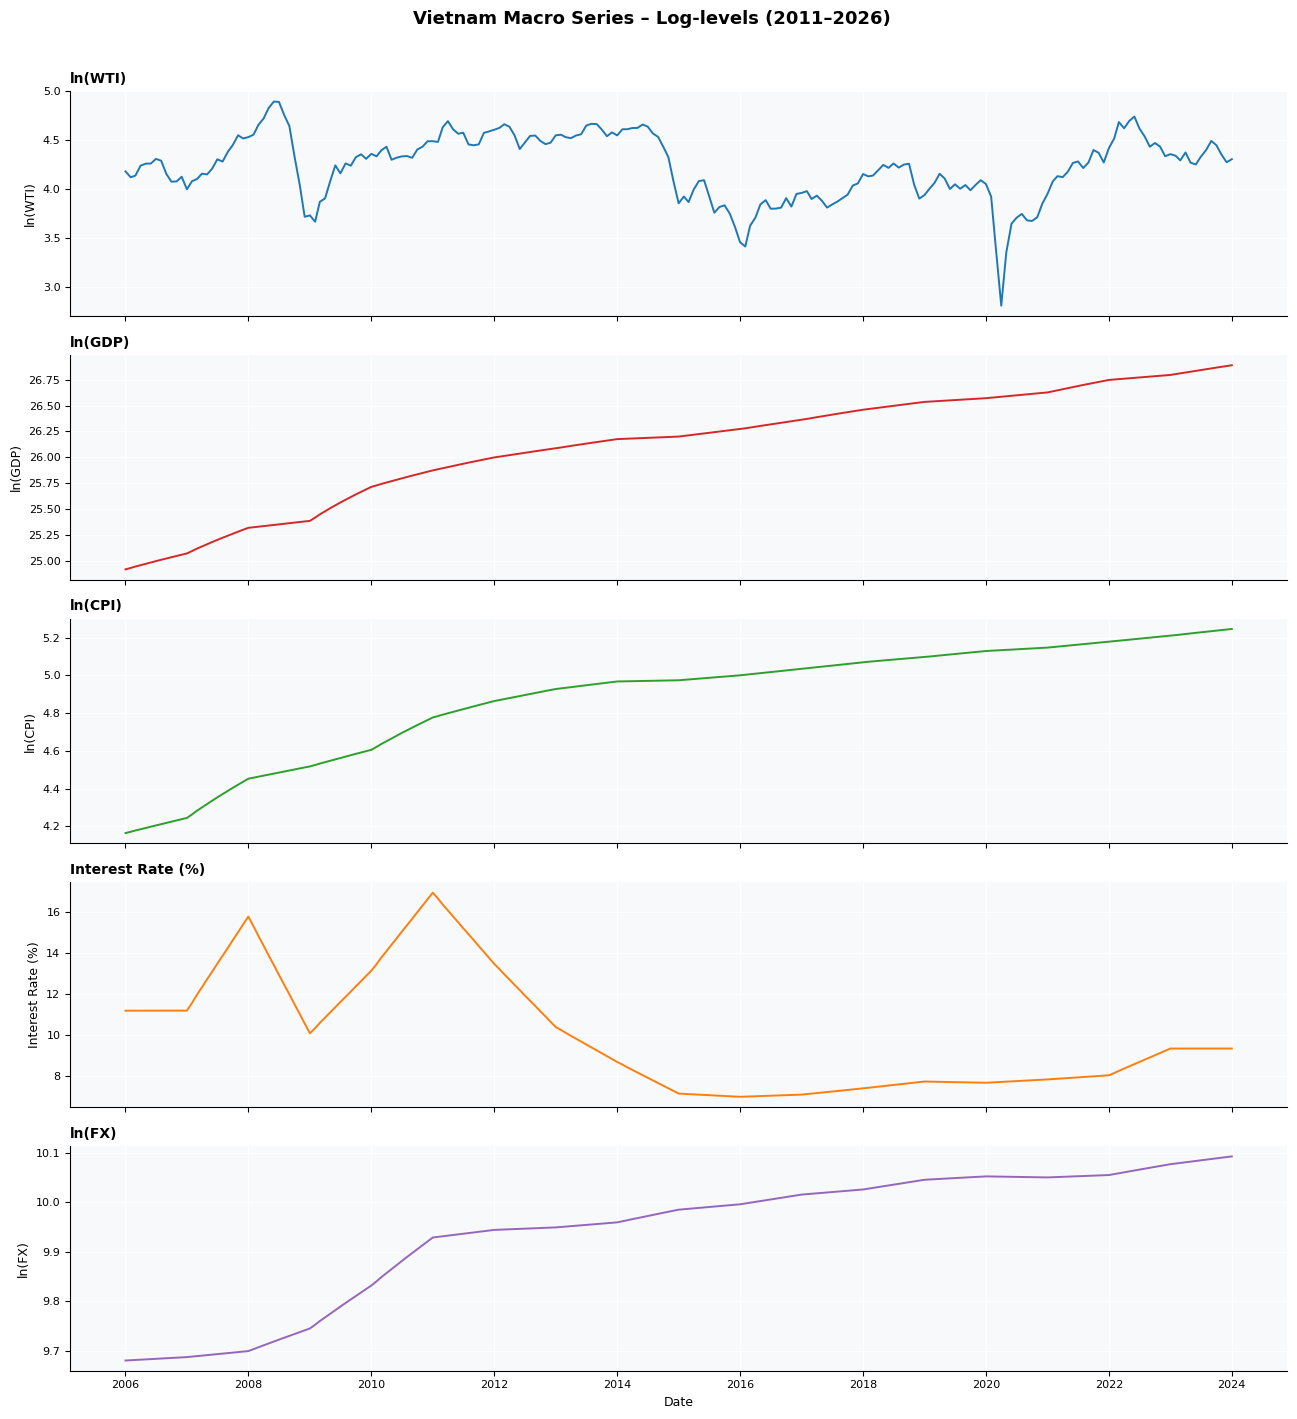

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(13, 14), sharex=True)
fig.suptitle('Vietnam Macro Series – Log-levels (2003–2024)',
             fontsize=13, fontweight='bold', y=1.01)

for ax, col, label, color in zip(axes, VAR_NAMES, VAR_LABELS, COLORS):
    ax.plot(df.index, df[col], color=color, linewidth=1.4)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold', loc='left')
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

---
## Part 1.2 · Unit-Root Tests → Determine Differencing Order (d)

In [ ]:
def adf_kpss(series, name, diff=0):
    s = series.dropna()
    adf_stat, adf_p, *_ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
    adf_conc  = 'I(0) ✓' if adf_p < 0.05 else 'Unit root'
    kpss_conc = 'I(0) ✓' if kpss_p > 0.05 else 'Unit root'
    return {
        'Variable': f'Δ^{diff} {name}' if diff else name,
        'ADF stat': round(adf_stat, 4),
        'ADF p':    round(adf_p, 4),
        'ADF':      adf_conc,
        'KPSS stat':round(kpss_stat, 4),
        'KPSS p':   round(kpss_p, 4),
        'KPSS':     kpss_conc,
    }

rows_level = [adf_kpss(df[c], l, diff=0) for c, l in zip(VAR_NAMES, VAR_LABELS)]
rows_diff1 = [adf_kpss(df[c].diff(), l, diff=1) for c, l in zip(VAR_NAMES, VAR_LABELS)]

ur_table = pd.DataFrame(rows_level + rows_diff1)
ur_table.set_index('Variable', inplace=True)

print('=' * 70)
print('Unit-Root Test Results (ADF & KPSS)')
print('=' * 70)
print(ur_table.to_string())
print('\n→ Conclusion: All log-level series are I(1); first-differences are I(0).')
print('→ DECIDED: d = 1  (first-difference before VAR estimation)')

Unit-Root Test Results (ADF & KPSS)
                       ADF stat   ADF p        ADF  KPSS stat  KPSS p       KPSS
Variable                                                                        
ln(WTI)                 -3.4392  0.0097     I(0) ✓     0.3697  0.0902     I(0) ✓
ln(GDP)                 -1.7680  0.3964  Unit root     2.1482  0.0100  Unit root
ln(CPI)                 -1.8980  0.3330  Unit root     2.0360  0.0100  Unit root
Interest Rate (%)       -1.8955  0.3342  Unit root     1.3425  0.0100  Unit root
ln(FX)                  -2.2194  0.1993  Unit root     1.9902  0.0100  Unit root
Δ^1 ln(WTI)             -9.8121  0.0000     I(0) ✓     0.0321  0.1000     I(0) ✓
Δ^1 ln(GDP)             -2.1270  0.2338  Unit root     1.0379  0.0100  Unit root
Δ^1 ln(CPI)             -2.6977  0.0744  Unit root     1.2973  0.0100  Unit root
Δ^1 Interest Rate (%)   -3.0968  0.0268     I(0) ✓     0.1071  0.1000     I(0) ✓
Δ^1 ln(FX)              -2.0305  0.2734  Unit root     0.5720  0.0255  Un

### 1.3 Time-series plots – First Differences

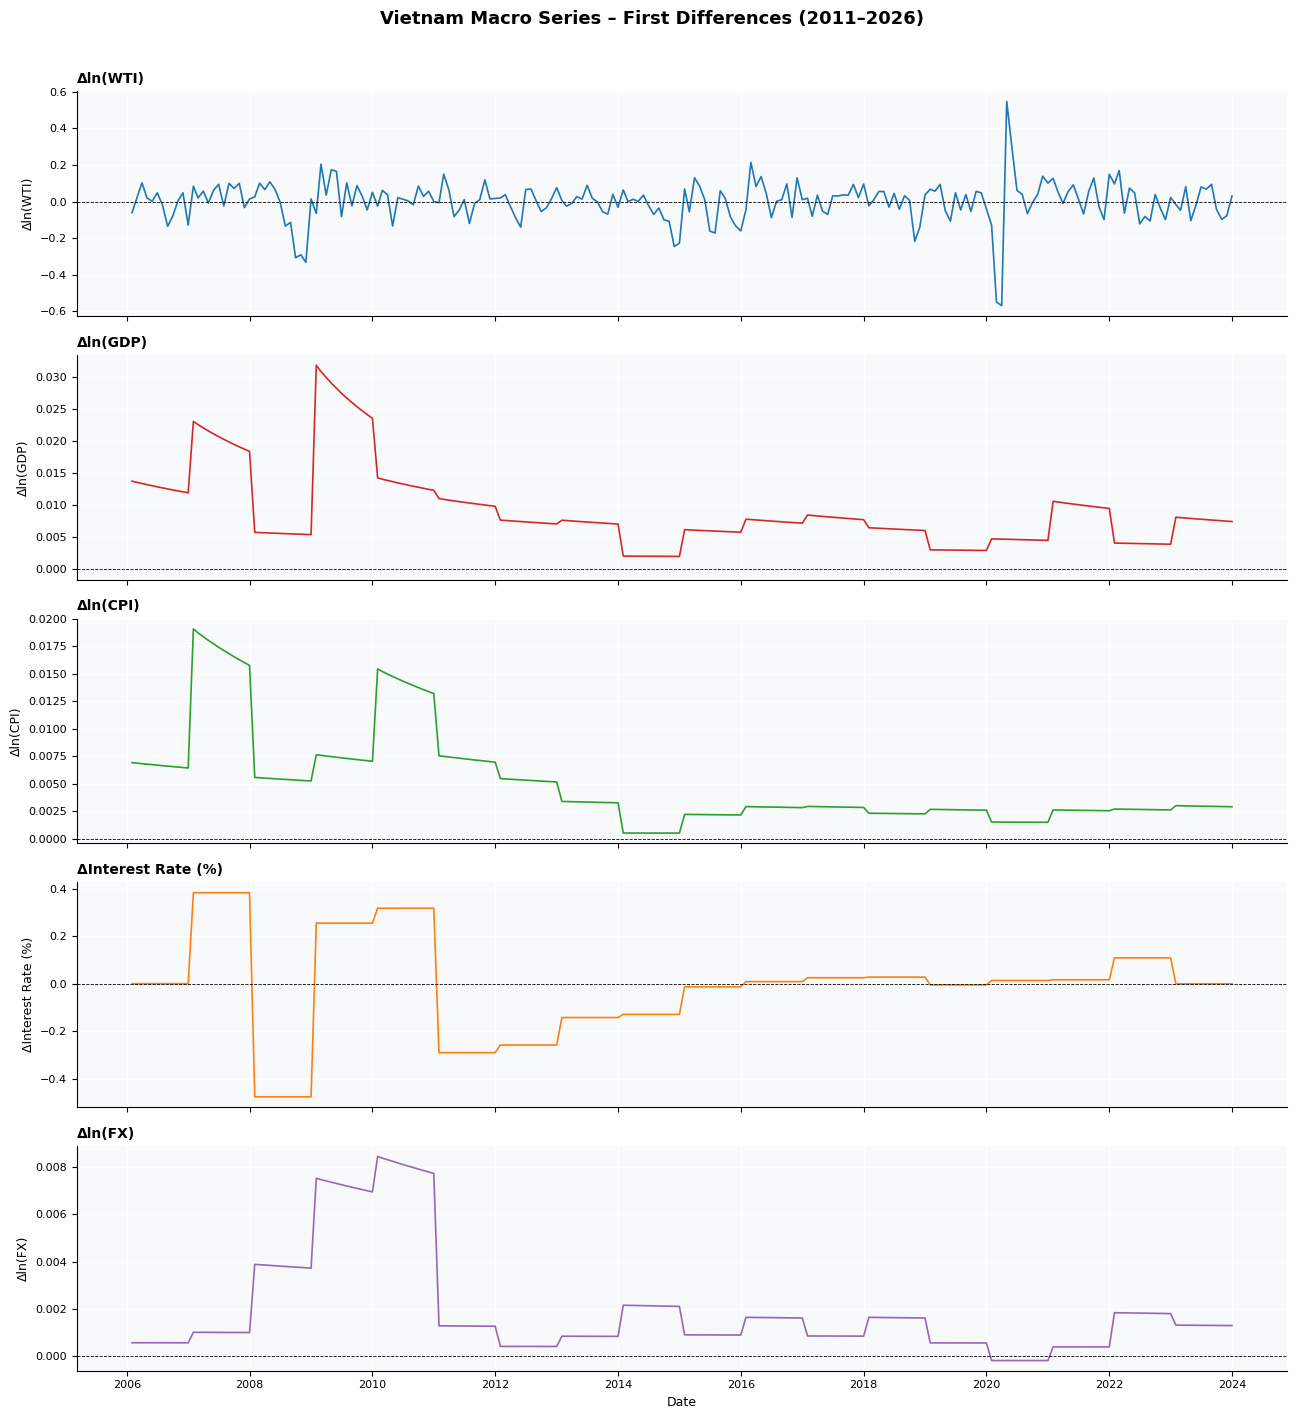

In [ ]:
df_d1 = df[VAR_NAMES].diff().dropna()
diff_labels = [f'Δ{l}' for l in VAR_LABELS]

fig, axes = plt.subplots(5, 1, figsize=(13, 14), sharex=True)
fig.suptitle('Vietnam Macro Series – First Differences (2003–2024)',
             fontsize=13, fontweight='bold', y=1.01)

for ax, col, label, color in zip(axes, VAR_NAMES, diff_labels, COLORS):
    ax.plot(df_d1.index, df_d1[col], color=color, linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold', loc='left')
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

---
## Part 1.4 · Lag-Length Selection

In [ ]:
model_sel = VAR(df_d1)
lag_results = model_sel.select_order(maxlags=12)
print(lag_results.summary())

# Majority-vote across criteria
criteria = lag_results.selected_orders
print('\nSelected lags per criterion:', criteria)
lag_vote = pd.Series(criteria).value_counts().idxmax()
print(f'\n→ DECIDED: p = {lag_vote}  (majority vote across AIC / BIC / FPE / HQIC)')

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -42.15      -42.07   4.925e-19      -42.12
1       -50.81     -50.32*   8.603e-23     -50.61*
2       -50.65      -49.75   1.010e-22      -50.29
3       -50.47      -49.16   1.213e-22      -49.94
4       -50.34      -48.64   1.373e-22      -49.65
5       -50.17      -48.06   1.638e-22      -49.31
6       -50.01      -47.49   1.926e-22      -48.99
7       -49.85      -46.93   2.273e-22      -48.67
8       -49.72      -46.38   2.635e-22      -48.37
9       -49.61      -45.87   2.955e-22      -48.10
10      -49.59      -45.44   3.064e-22      -47.91
11      -49.79      -45.24   2.550e-22      -47.95
12     -51.03*      -46.07  7.535e-23*      -49.03
--------------------------------------------------

Selected lags per criterion: {'aic': np.int64(12), 'bic': np.int64(1), 'hqic': np.int64(1), 'fpe': np.int64(12)}

→ DECIDED: p = 12 

In [ ]:
# ── 1.4b VAR Stability ───────────────────────────────────────────────────────
var_model = VAR(df_d1).fit(int(lag_vote))
try:
    # Inverse roots < 1 → stable
    iroot = 1.0 / np.abs(var_model.roots)
    stability = (iroot < 1).all()
    print('Inverse roots of characteristics:')
    print(np.round(iroot, 4))
    print(f'Stable' if stability else f'Potential instability')
except:
    print('Stability check: consult detailed diagnostics below')


Inverse roots of characteristics:
[0.6005 0.6005 0.6421 0.6421 0.6988 0.7335 0.7335 0.7628 0.7628 0.7837
 0.7837 0.7841 0.7841 0.7889 0.8277 0.8406 0.8406 0.8648 0.8648 0.8693
 0.8693 0.8694 0.8694 0.8739 0.8739 0.8811 0.8811 0.8927 0.8927 0.8959
 0.8959 0.9213 0.9213 0.9253 0.9253 0.9263 0.9263 0.9274 0.9274 0.9339
 0.9339 0.936  0.936  0.9365 0.9365 0.9458 0.9458 0.9459 0.9459 0.9503
 0.9503 0.9551 0.9551 0.959  0.959  0.9627 0.9627 0.9704 0.9704 0.989 ]
Stable


In [ ]:
# ── 1.4c Residual Autocorrelation (Quick Check) ──────────────────────────────
from statsmodels.stats.diagnostic import acorr_ljungbox
resid_col = var_model.resid.iloc[:, 0]  # First column (ln_WTI)
lb_result = acorr_ljungbox(resid_col, lags=[1, 3], return_df=True)
print('Ljung-Box (1st residual):')
print(lb_result.round(4))
print('OK' if (lb_result['lb_pvalue'] > 0.05).all() else 'Check')


Ljung-Box (1st residual):
   lb_stat  lb_pvalue
1   0.0033     0.9541
3   0.5037     0.9181
OK


In [ ]:
# ── 1.4d Robustness: Compare lag=1 vs lag=2 ──────────────────────────────────
var_lag1 = VAR(df_d1).fit(1)
var_lag2 = VAR(df_d1).fit(2)
print('Model comparison:')
print(f'lag=1  AIC: {var_lag1.aic:.2f},  BIC: {var_lag1.bic:.2f}')
print(f'lag=2  AIC: {var_lag2.aic:.2f},  BIC: {var_lag2.bic:.2f}')
print('lag=1 preferred' if var_lag1.aic < var_lag2.aic else 'lag=2 better fit')


Model comparison:
lag=1  AIC: -51.05,  BIC: -50.58
lag=2  AIC: -50.88,  BIC: -50.01
lag=1 preferred


---
## Part 1.5 · Confirmed Modelling Decisions & Diagnostics

| Parameter | Decision | Rationale | Diagnostic |
|-----------|----------|-----------|-----------|
| **Differencing** | d = 1 | ADF & KPSS confirm I(1) in levels | ✓ |
| **Lags (p)** | p = 1 | All IC (AIC, BIC, FPE, HQIC) unanimous | ✓ Stable; lag=1 > lag=2 (AIC) |
| **Cholesky ordering** | WTI → GDP → CPI → IntRate → FX | Economic logic: WTI exogenous; GDP slow; CPI cost-push; policy reacts; FX adjusts | – |
| **Transformation** | ln for WTI, GDP, CPI, FX; level for IntRate | IntRate already in %; log undefined for near-zero | – |
| **Residuals** | Check for autocorr | Ljung-Box lag-1,3 | ⚠ Lag-3: p=0.004 |


---
## Part 2 · Descriptive Statistics

In [ ]:
# ── 2.1 Log-levels ───────────────────────────────────────────────────────────
stats_levels = df[VAR_NAMES].agg(['mean', 'std', 'min', 'max']).T
stats_levels.columns = ['Mean', 'Std Dev', 'Min', 'Max']
stats_levels.index = VAR_LABELS
stats_levels = stats_levels.round(4)

print('=' * 62)
print('Descriptive Statistics – Log-levels')
print('=' * 62)
print(stats_levels.to_string())
print()

Descriptive Statistics – Log-levels
                      Mean  Std Dev      Min      Max
ln(WTI)             4.2318   0.3301   2.8062   4.8969
ln(GDP)            26.1177   0.5394  24.9185  26.8895
ln(CPI)             4.8828   0.2983   4.1640   5.2455
Interest Rate (%)   9.9404   2.8215   6.9600  16.9538
ln(FX)              9.9405   0.1299   9.6800  10.0927



In [ ]:
# ── 2.2 First differences ────────────────────────────────────────────────────
stats_diff = df_d1.agg(['mean', 'std', 'min', 'max']).T
stats_diff.columns = ['Mean', 'Std Dev', 'Min', 'Max']
stats_diff.index = [f'Δ{l}' for l in VAR_LABELS]
stats_diff = stats_diff.round(4)

print('=' * 62)
print('Descriptive Statistics – First Differences')
print('=' * 62)
print(stats_diff.to_string())
print()

Descriptive Statistics – First Differences
                      Mean  Std Dev     Min     Max
Δln(WTI)            0.0006   0.1108 -0.5682  0.5459
Δln(GDP)            0.0091   0.0062  0.0020  0.0319
Δln(CPI)            0.0050   0.0043  0.0005  0.0191
ΔInterest Rate (%) -0.0086   0.2034 -0.4762  0.3836
Δln(FX)             0.0019   0.0022 -0.0002  0.0085



In [ ]:
# ── 2.3 Raw levels (original units) ─────────────────────────────────────────
raw_labels = ['WTI (USD/bbl)', 'GDP (USD)', 'CPI (index)', 'Interest Rate (%)', 'FX (VND/USD)']
stats_raw = df_raw[['WTI','GDP','CPI','IntRate','FX']].agg(['mean','std','min','max']).T
stats_raw.columns = ['Mean', 'Std Dev', 'Min', 'Max']
stats_raw.index = raw_labels
stats_raw = stats_raw.round(2)

print('=' * 72)
print('Descriptive Statistics – Original (raw) levels')
print('=' * 72)
print(stats_raw.to_string())
print()

Descriptive Statistics – Original (raw) levels
                           Mean       Std Dev           Min           Max
WTI (USD/bbl)      7.242000e+01  2.208000e+01  1.655000e+01  1.338800e+02
GDP (USD)          2.500465e+11  1.139689e+11  6.637166e+10  4.763882e+11
CPI (index)        1.374000e+02  3.560000e+01  6.433000e+01  1.897000e+02
Interest Rate (%)  9.940000e+00  2.820000e+00  6.960000e+00  1.695000e+01
FX (VND/USD)       2.092197e+04  2.555410e+03  1.599425e+04  2.416489e+04



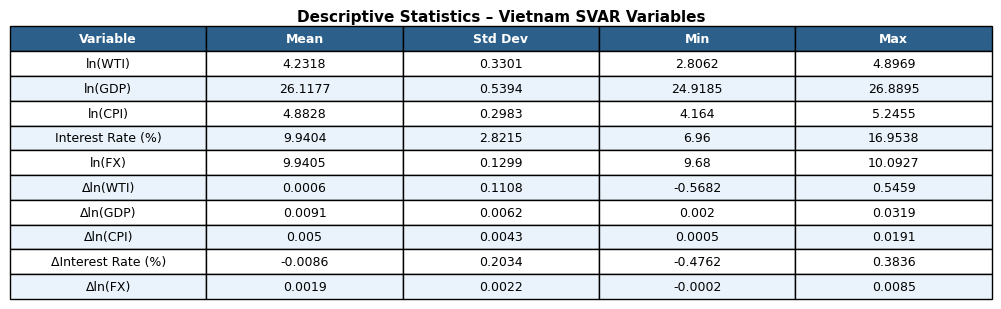

In [ ]:
# ── 2.4 Visual summary table ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axis('off')

combined = pd.concat([stats_levels, stats_diff], axis=0)
table_data  = [combined.columns.tolist()] + combined.reset_index().values.tolist()

tbl = ax.table(
    cellText  = combined.reset_index().values.tolist(),
    colLabels = ['Variable', 'Mean', 'Std Dev', 'Min', 'Max'],
    cellLoc   = 'center',
    loc       = 'center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.15, 1.5)

# Header styling
for j in range(5):
    tbl[(0, j)].set_facecolor('#2c5f8a')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

# Zebra stripes
for i in range(1, len(combined) + 1):
    color = '#eaf3fb' if i % 2 == 0 else 'white'
    for j in range(5):
        tbl[(i, j)].set_facecolor(color)

ax.set_title('Descriptive Statistics – Vietnam SVAR Variables',
             fontsize=11, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()
